# Lambda Experiments

## Tranining

In [1]:
import sys
sys.path.append("..")

from source.system import SystemParams
from source.policy import NeuralPolicy

from source.utils import read_csv
from source.training import train_net

In [8]:
import torch
import os

EPOCHS       = 1000
LR           = 5e-4
WEIGHT_DECAY = 1e-5
BATCH_SIZE   = 1000
SEED_BASE    = 123
LAMBDA_COST  = [0.0, 0.1, 0.25, 0.5]
ALPHA_GRID   = 0.0
DEVICE       = torch.device("cpu")

params = SystemParams()
S0_single = torch.tensor([[0., 0., 100., 0.01]], device=DEVICE)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

CHECKPOINT_DIR = "../checkpoints/lambda_experiments"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Same initial weights for all lambda experiments
torch.manual_seed(SEED_BASE)
initial_policy = NeuralPolicy().to(DEVICE)
initial_state = {
    k: v.detach().cpu().clone()
    for k, v in initial_policy.state_dict().items()
}

for lambda_cost in LAMBDA_COST:

    print("=" * 50)
    print(f"Training: lambda={lambda_cost}")

    # Reset policy to the same initial weights
    policy = NeuralPolicy().to(DEVICE)
    policy.load_state_dict(initial_state)

    opt = torch.optim.AdamW(
        policy.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    res = train_net(
        policy=policy,
        optimizer=opt,
        device=DEVICE,
        params=params,
        S0_single=S0_single,
        endog_history=price_history,
        future_endog=future_price,
        epochs=EPOCHS,
        lambda_cost=lambda_cost,
        alpha_grid=ALPHA_GRID,
        batch_size=BATCH_SIZE,
        seed_base=SEED_BASE,
        verbose=True
    )

    print(f"lambda: {lambda_cost}, best J: {res['best_J']}")

    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}.pt"
    path = os.path.join(CHECKPOINT_DIR, filename)

    checkpoint = {
        "lambda_cost": lambda_cost,
        "alpha_grid": ALPHA_GRID,
        "best_J": res["best_J"],
        "policy_state_dict": res["best_state"],
        "J_train_hist": res["J_train_hist"],
        "J_eval_hist": res["J_eval_hist"],
        "seed_base": SEED_BASE,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    }

    if "best_epoch" in res:
        checkpoint["best_epoch"] = res["best_epoch"]

    torch.save(checkpoint, path)

    print(f"Saved best policy: {path}\n")

Training: lambda=0.0
[050] J_train=-9.4682 | J_eval(det)=-9.7222
[100] J_train=-12.9618 | J_eval(det)=-12.9657
[150] J_train=-14.4694 | J_eval(det)=-14.2639
[200] J_train=-17.3172 | J_eval(det)=-16.7000
[250] J_train=-19.1732 | J_eval(det)=-17.9740
[300] J_train=-20.7378 | J_eval(det)=-18.8588
[350] J_train=-21.8021 | J_eval(det)=-19.5487
[400] J_train=-23.1731 | J_eval(det)=-20.1940
[450] J_train=-24.1983 | J_eval(det)=-20.9799
[500] J_train=-25.3548 | J_eval(det)=-21.7083
[550] J_train=-25.8399 | J_eval(det)=-22.1439
[600] J_train=-26.0871 | J_eval(det)=-22.2686
[650] J_train=-26.6671 | J_eval(det)=-22.2942
[700] J_train=-26.9475 | J_eval(det)=-22.4957
[750] J_train=-26.9691 | J_eval(det)=-22.5961
[800] J_train=-26.8747 | J_eval(det)=-22.7431
[850] J_train=-27.0653 | J_eval(det)=-22.7422
[900] J_train=-27.4254 | J_eval(det)=-22.7819
[950] J_train=-27.2867 | J_eval(det)=-22.8708
[1000] J_train=-27.5232 | J_eval(det)=-22.8744

Training ready in 485.2s. Epoch: 996. Best J=-27.9179
lambd

## Traning convergence

In [10]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

CHECKPOINT_DIR = "../checkpoints/lambda_experiments"
LAMBDA_COST = [0.0, 0.1, 0.25, 0.5]

checkpoints = {}

for lambda_cost in LAMBDA_COST:
    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}.pt"
    path = os.path.join(CHECKPOINT_DIR, filename)

    ckpt = torch.load(path, map_location="cpu")
    checkpoints[lambda_cost] = ckpt

    print("=" * 50)
    print(f"lambda = {lambda_cost}")
    print(f"best_J = {ckpt['best_J']}")
    print(f"J_train_hist length = {len(ckpt['J_train_hist'])}")
    print(f"J_eval_hist length  = {len(ckpt['J_eval_hist'])}")

lambda = 0.0
best_J = -27.91788101196289
J_train_hist length = 1000
J_eval_hist length  = 20
lambda = 0.1
best_J = -25.06434440612793
J_train_hist length = 1000
J_eval_hist length  = 20
lambda = 0.25
best_J = -21.495698928833008
J_train_hist length = 1000
J_eval_hist length  = 20
lambda = 0.5
best_J = -18.380971908569336
J_train_hist length = 1000
J_eval_hist length  = 20


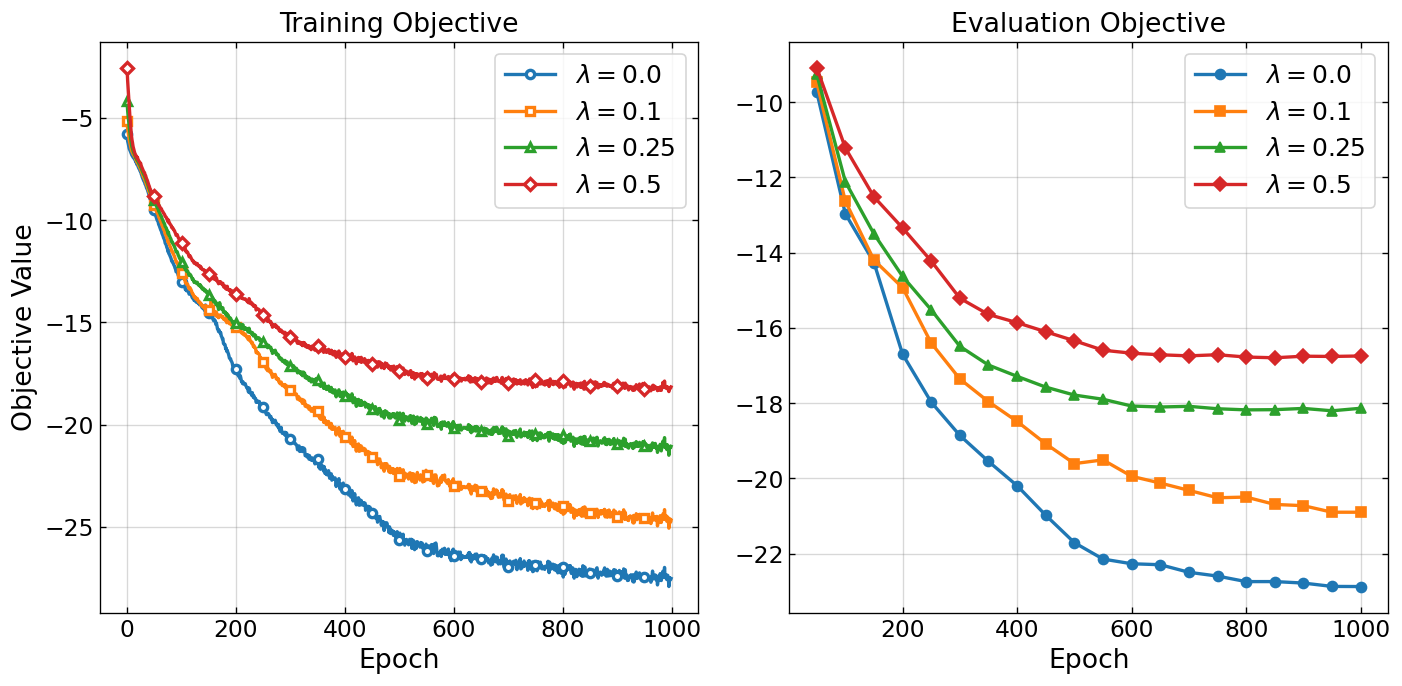

In [75]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

CHECKPOINT_DIR = "../checkpoints/lambda_experiments"
LAMBDA_COST = [0.0, 0.1, 0.25, 0.5]

fig, axs = plt.subplots(
    1, 2,
    figsize=(12, 6),
    sharey=False
)

markers = ["o", "s", "^", "D"]

for marker, lambda_cost in zip(markers, LAMBDA_COST):

    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}.pt"
    path = os.path.join(CHECKPOINT_DIR, filename)

    ckpt = torch.load(path, map_location="cpu")

    J_train = ckpt["J_train_hist"]
    J_eval = ckpt["J_eval_hist"]

    eval_epochs = np.arange(50, len(J_train) + 1, 50)

    axs[0].plot(
        J_train,
        linestyle="-",
        marker=marker,
        markevery=50,
        markersize=5,
        linewidth=2,
        markerfacecolor="white",
        markeredgewidth=2,
        label=fr"$\lambda={lambda_cost}$"
    )

    axs[1].plot(
        eval_epochs,
        J_eval,
        linestyle="-",
        marker=marker,
        markersize=6,
        linewidth=2,
        label=fr"$\lambda={lambda_cost}$"
    )

axs[0].set_title("Training Objective")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Objective Value")
axs[0].grid(True, alpha=0.3)

axs[1].set_title("Evaluation Objective")
axs[1].set_xlabel("Epoch")
axs[1].grid(True, alpha=0.3)

axs[0].legend()
axs[1].legend()

plt.tight_layout()

plt.savefig(
    "../figures/lambda_experiments/training_evaluation_objective.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "../figures/lambda_experiments/training_evaluation_objective.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparison

In [47]:
from source.simulation import sample_initial_state, rollout_trajectory
from source.stochastic_processes import make_price_function

DEVICE = torch.device("cpu")

POLICY_DIR = "../checkpoints/lambda_experiments"
ROLLOUT_DIR = "../checkpoints/rollouts"
os.makedirs(ROLLOUT_DIR, exist_ok=True)

LAMBDA_COST = [0.0, 0.1, 0.25, 0.5]

ALPHA_GRID = 0.0
BATCH_SIZE = 1000
SEED_BASE = 123

params = SystemParams()

S0 = sample_initial_state(
    batch_size=BATCH_SIZE,
    params=params,
    device=DEVICE,
    seed=SEED_BASE
)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]



rollout_results = {}

for lambda_cost in LAMBDA_COST:

    next_price_fn_eval = make_price_function(
        price_history,
        future_price,
        params
    )

    print("=" * 50)
    print(f"Rollout: lambda={lambda_cost}")

    filename = f"policy_lambda_{str(lambda_cost).replace('.', '_')}.pt"
    path = os.path.join(POLICY_DIR, filename)

    ckpt = torch.load(path, map_location=DEVICE)

    policy = NeuralPolicy().to(DEVICE)
    policy.load_state_dict(ckpt["policy_state_dict"])
    policy.eval()

    with torch.no_grad():
        history = rollout_trajectory(
            policy=policy,
            S0=S0,
            lambda_cost=lambda_cost,
            alpha_grid=ALPHA_GRID,
            params=params,
            next_price_fn=next_price_fn_eval,
            stochastic=True,
            seed=SEED_BASE,
            device=DEVICE,
        )

    lambda_key = str(lambda_cost)

    rollout_results[lambda_key] = history

    print(f"J_episode: {history['J_episode']}")

rollout_path = os.path.join(ROLLOUT_DIR, "lambda_experiment.pt")

torch.save(rollout_results, rollout_path)

print(f"\nSaved rollouts: {rollout_path}")

Rollout: lambda=0.0
J_episode: -27.103437423706055
Rollout: lambda=0.1
J_episode: -23.84464454650879
Rollout: lambda=0.25
J_episode: -20.034046173095703
Rollout: lambda=0.5
J_episode: -16.939987182617188

Saved rollouts: ../checkpoints/rollouts\lambda_experiment.pt


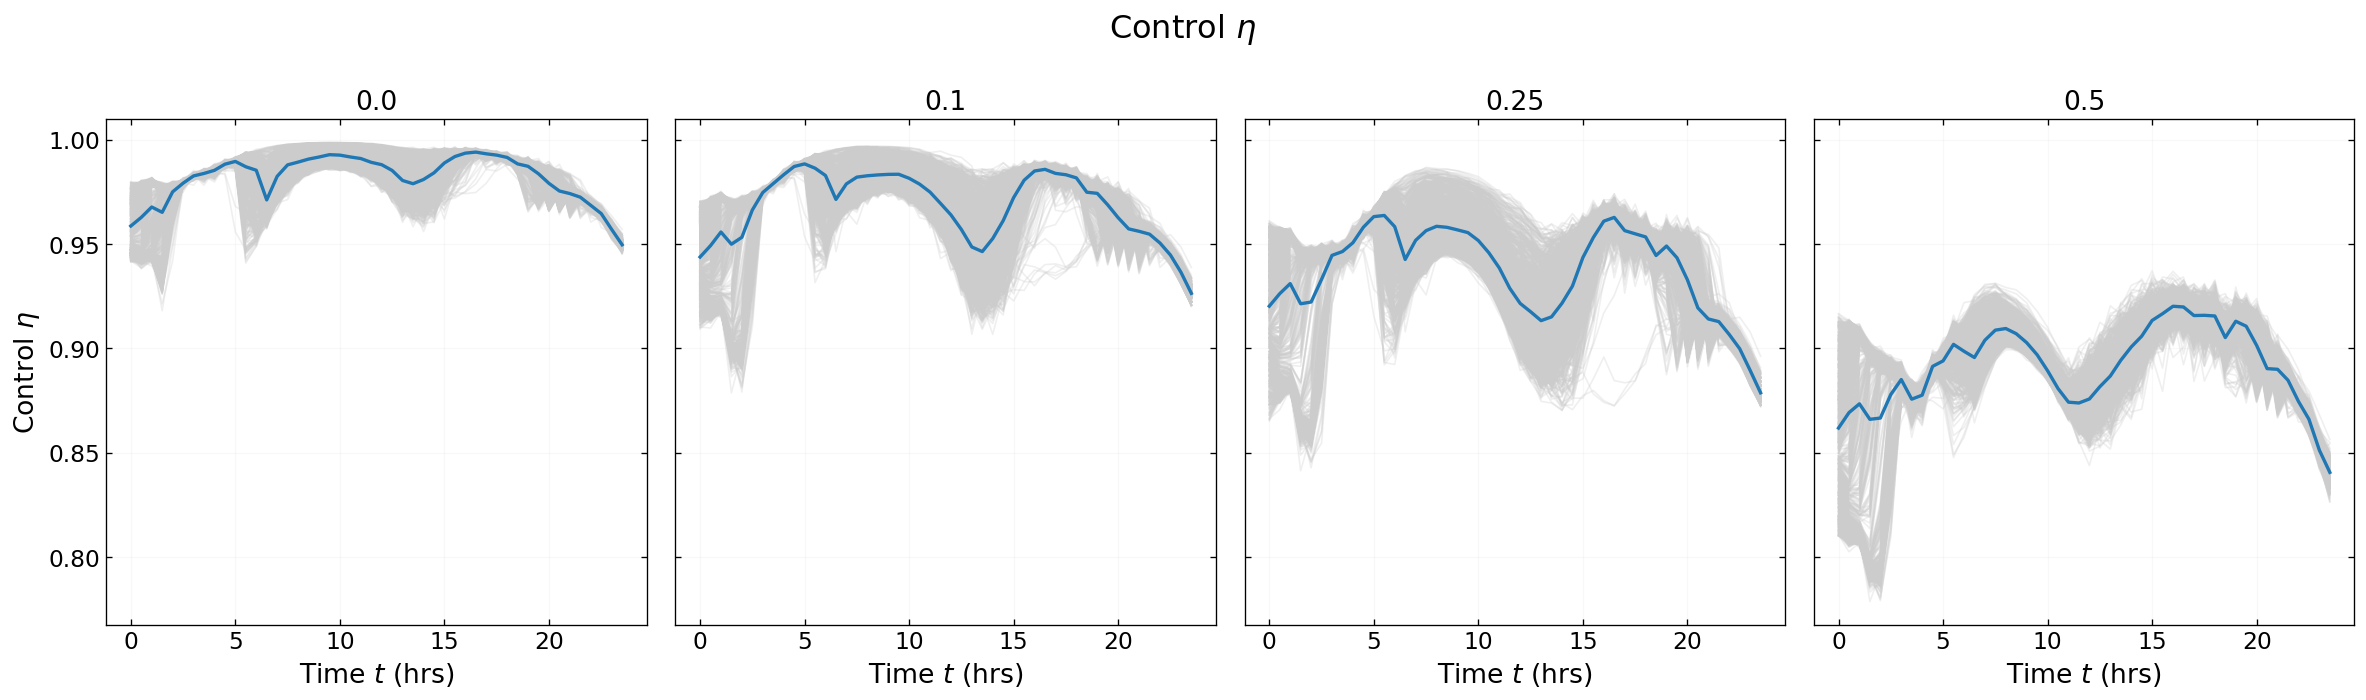

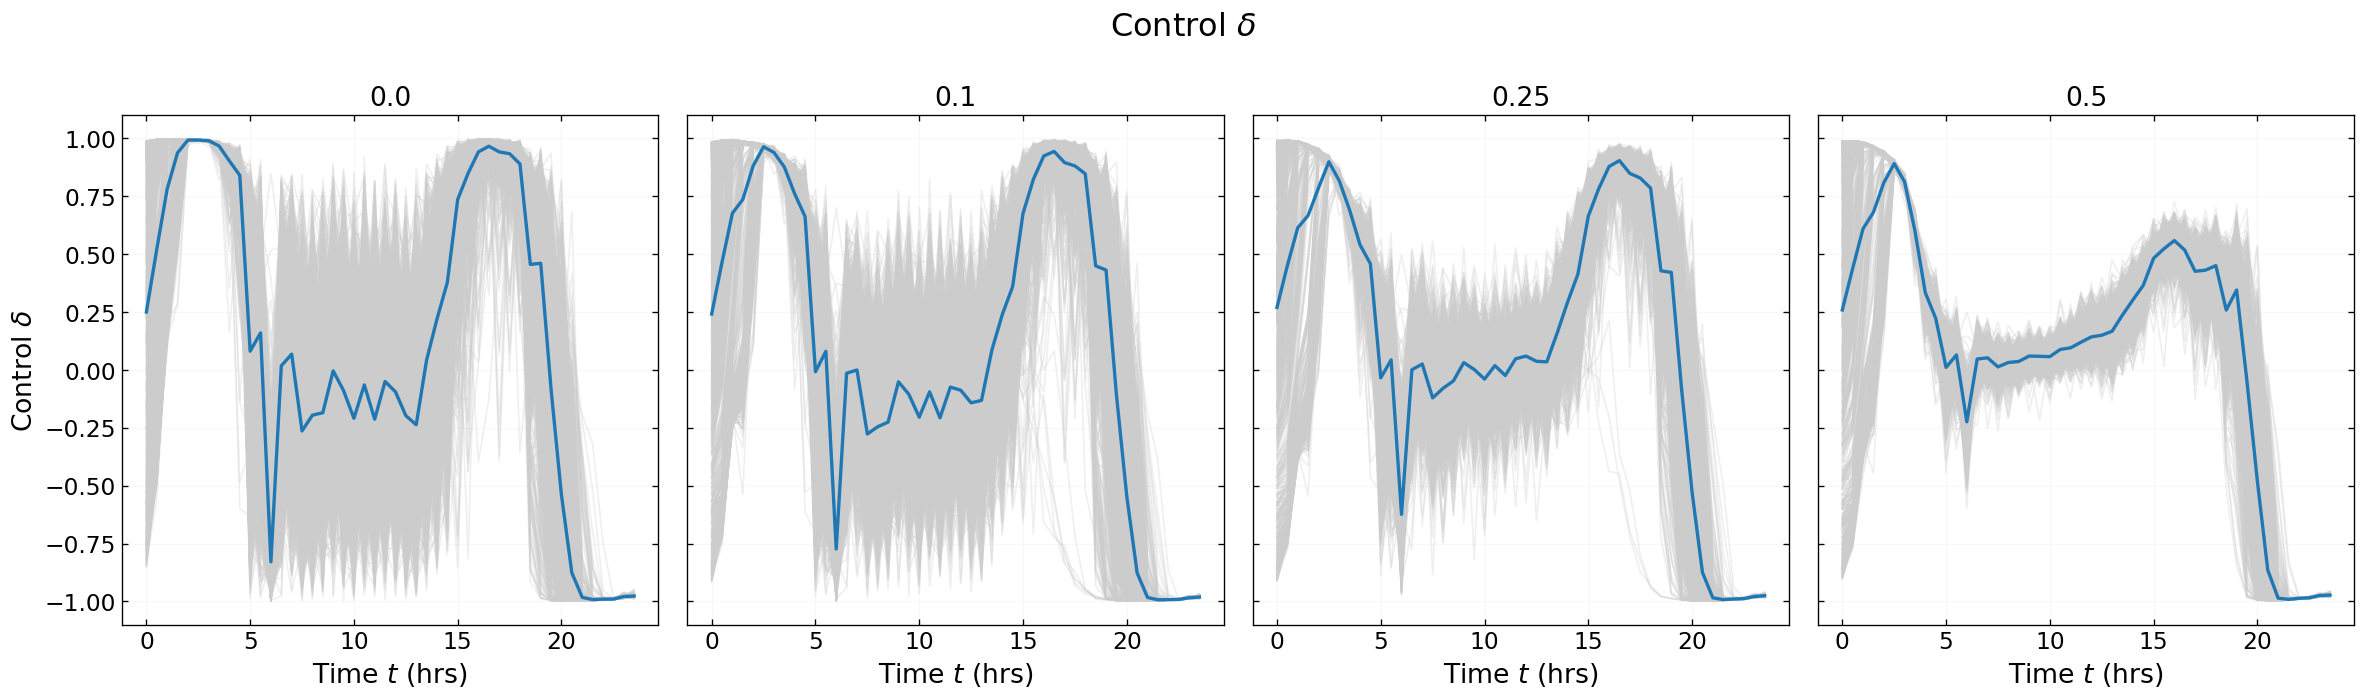

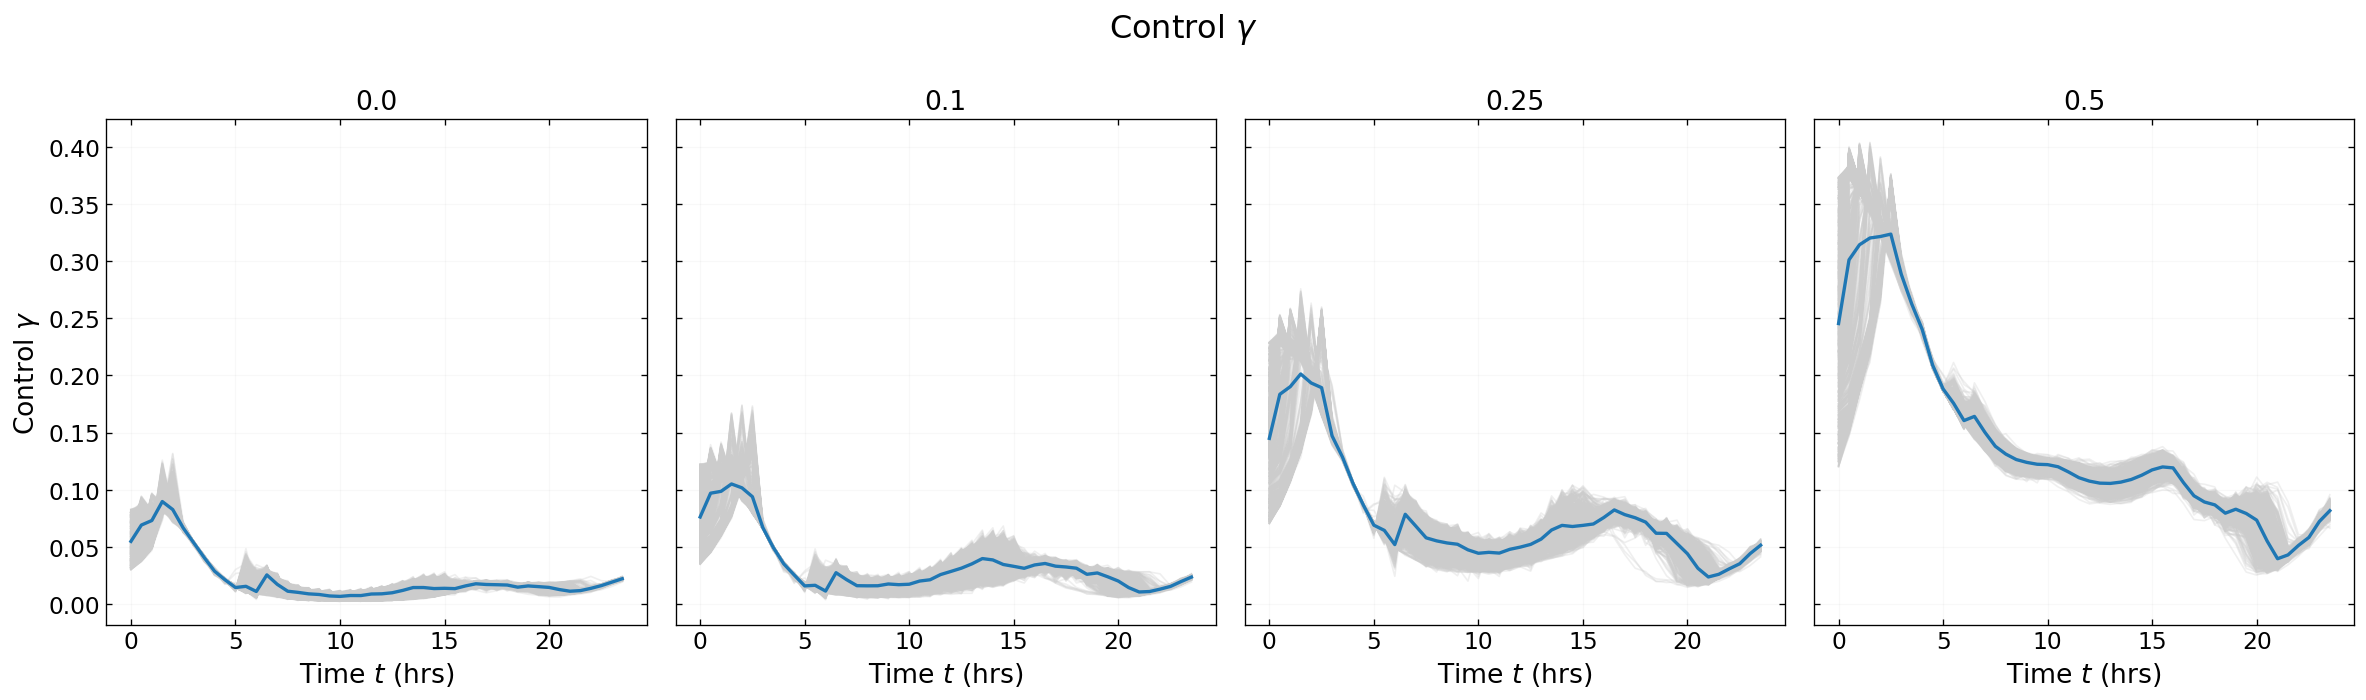

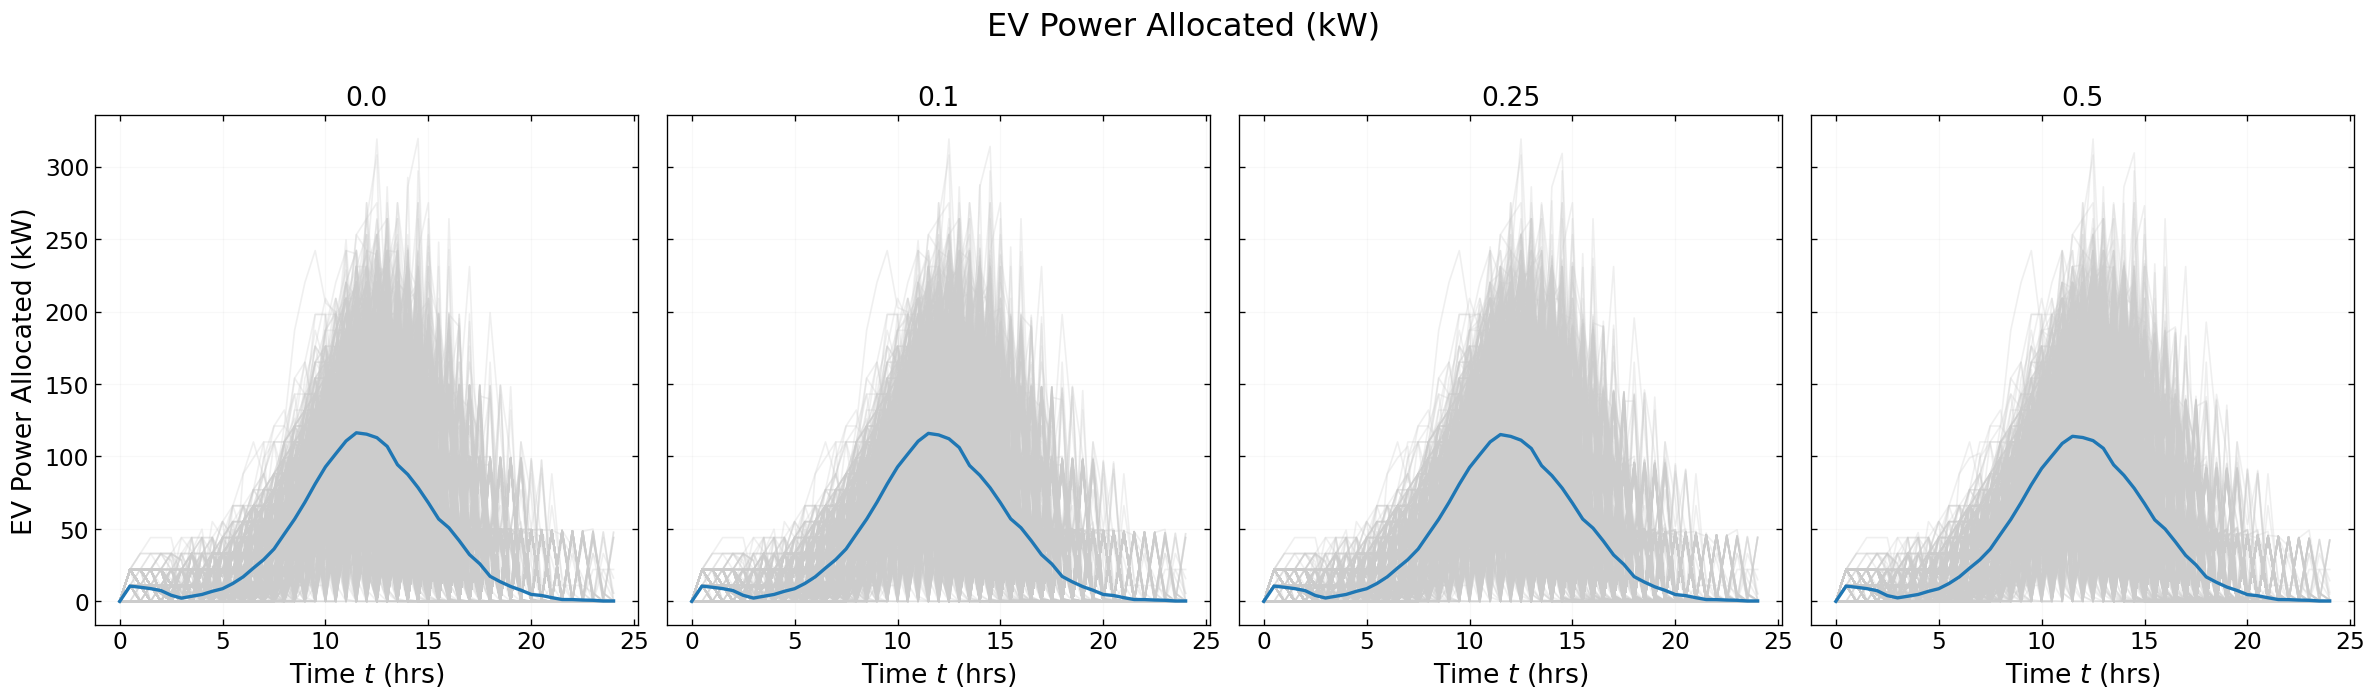

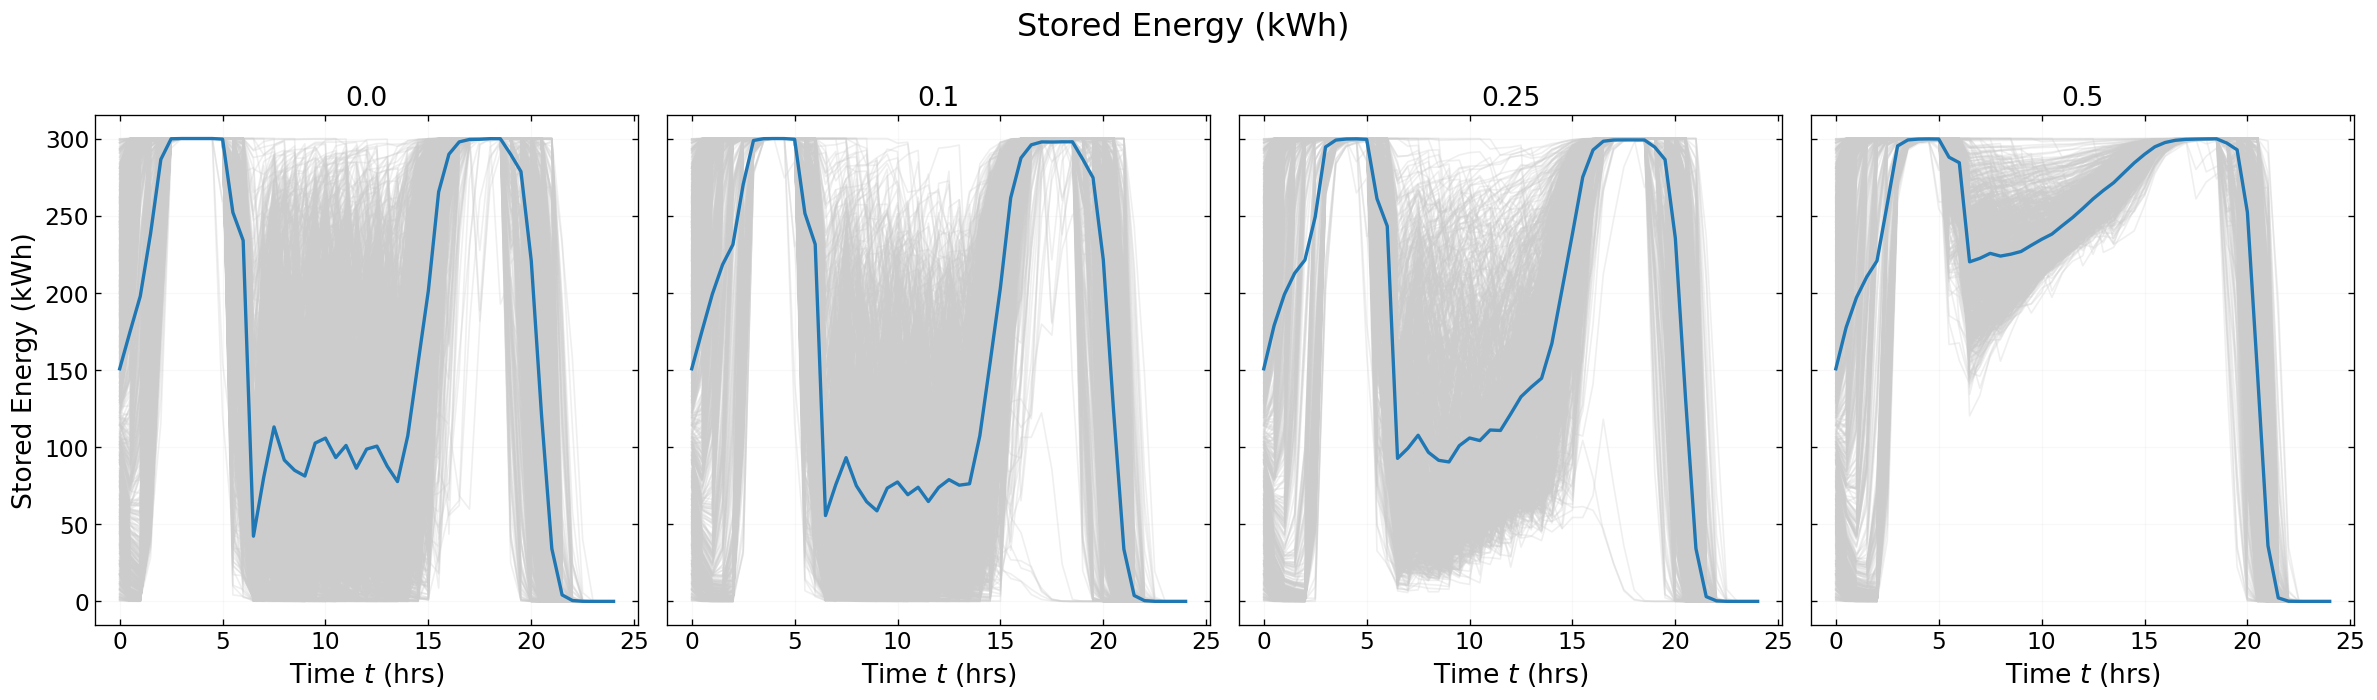

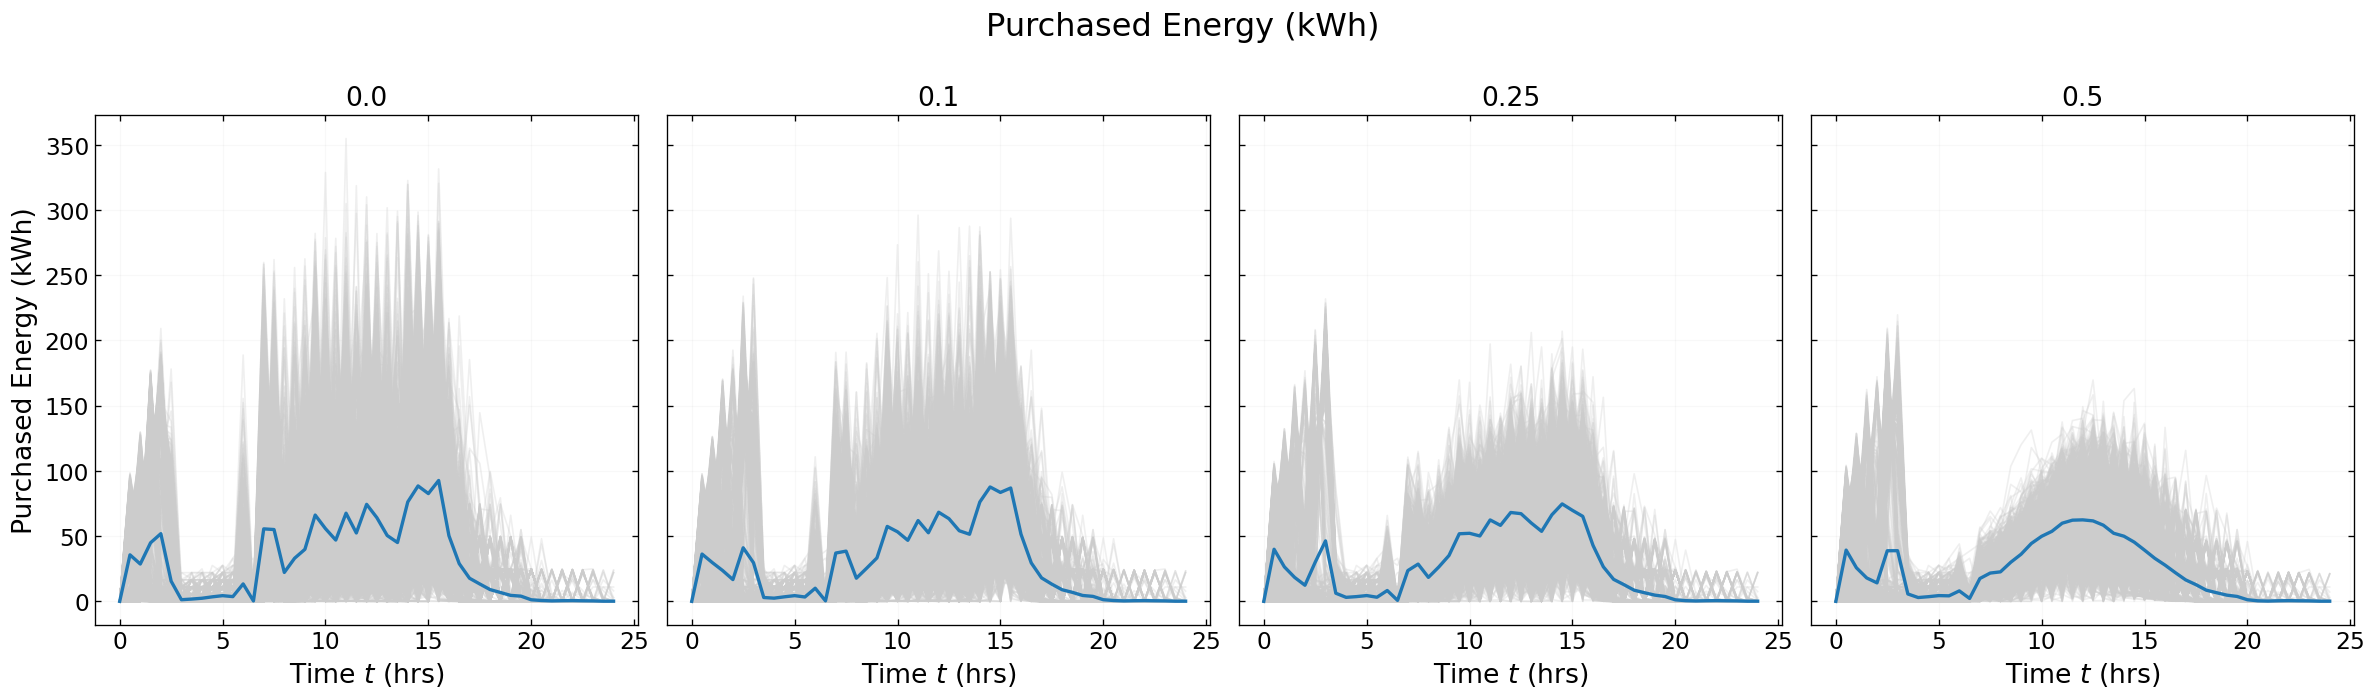

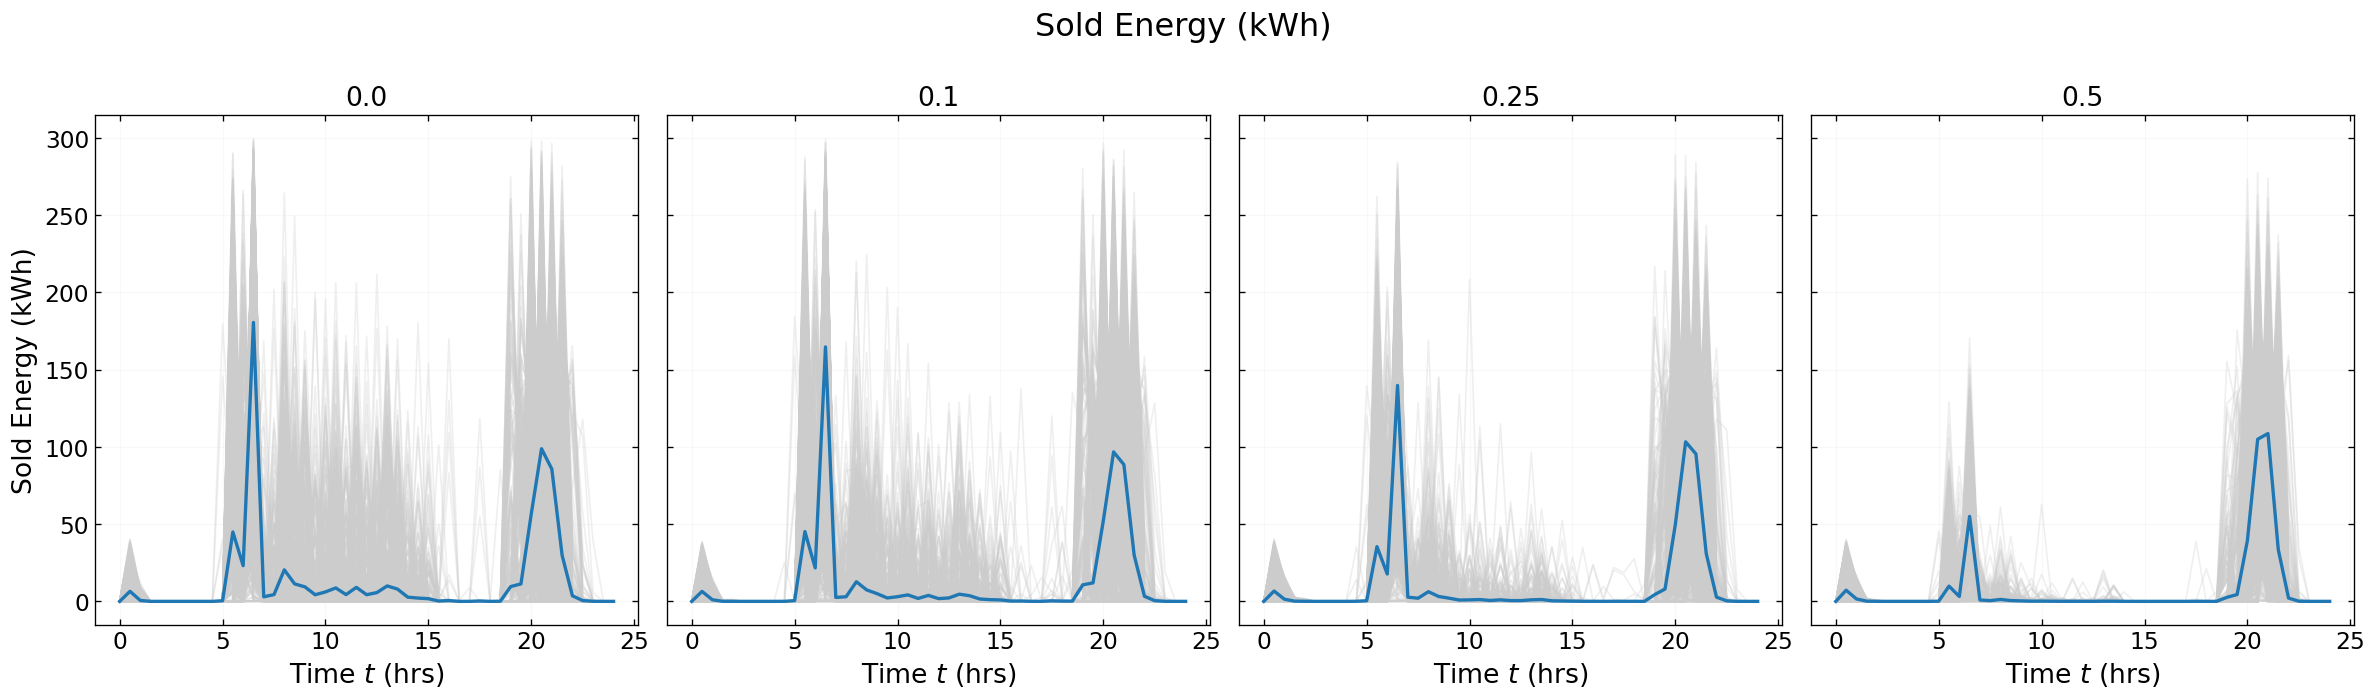

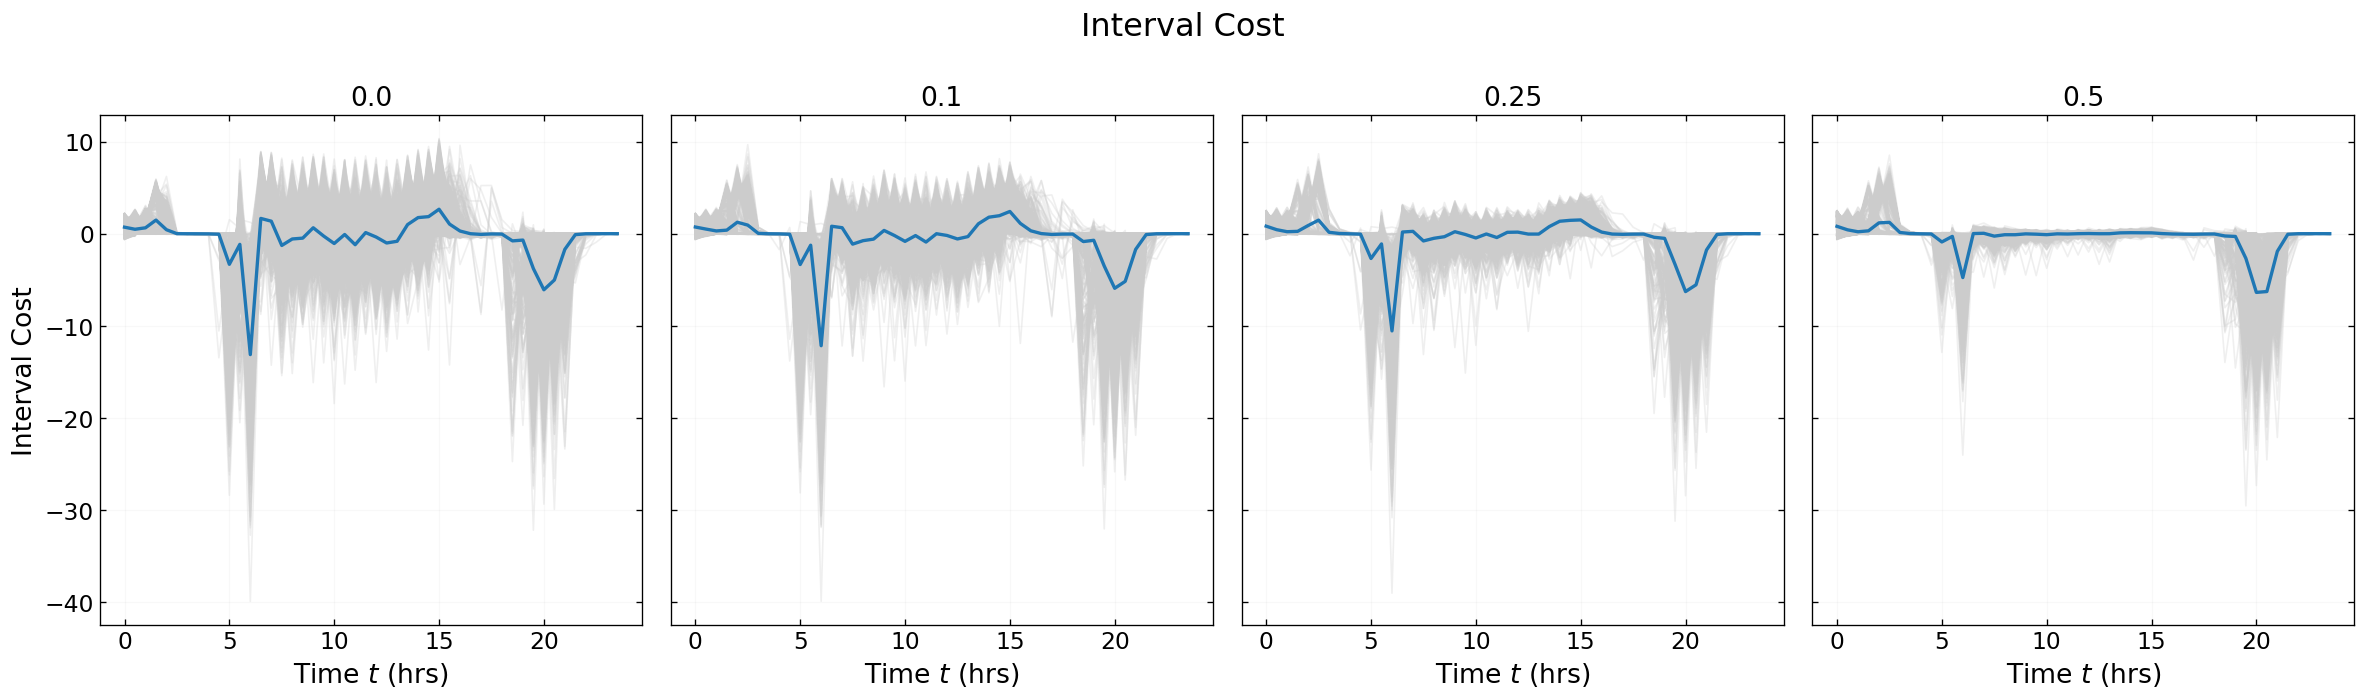

In [77]:
from source.plotting import plot_controls_summary, plot_variable_across_policies

SAVE_DIR = "../figures/lambda_experiments"

plots = [
    ("eta",   r"Control $\eta$",             "control_eta.pdf"),
    ("delta", r"Control $\delta$",           "control_delta.pdf"),
    ("gamma", r"Control $\gamma$",           "control_gamma.pdf"),
    ("q",     "EV Power Allocated (kW)",     "ev_power_allocated.pdf"),
    ("E",     "Stored Energy (kWh)",         "stored_energy.pdf"),
    ("Ub",    "Purchased Energy (kWh)",      "purchased_energy.pdf"),
    ("Us",    "Sold Energy (kWh)",           "sold_energy.pdf"),
    ("c",     "Interval Cost",               "interval_cost.pdf"),
]

for key, ylabel, filename in plots:

    full_path = os.path.join(SAVE_DIR, filename)

    plot_variable_across_policies(
        rollout_results,
        key,
        ylabel,
        filename=full_path
    )


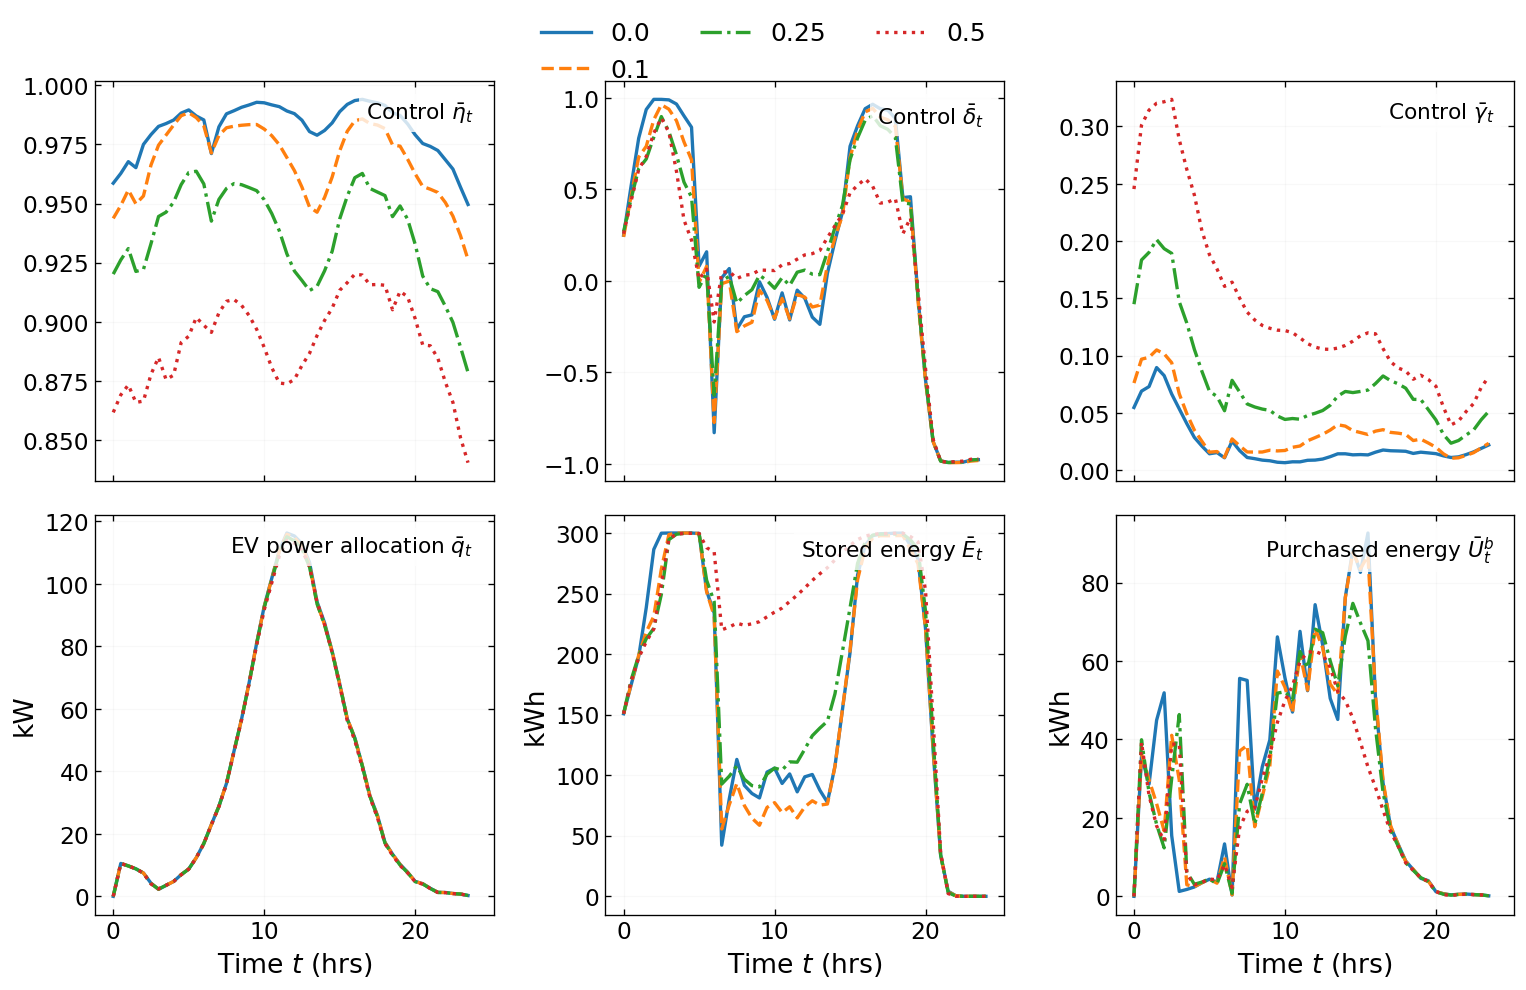

In [74]:
plot_controls_summary(
    rollout_results,
    save_path="../figures/lambda_experiments/controls_summary.pdf"
)

In [ ]:
from source.utils import summarize_histories

df = summarize_histories(rollout_results)
print(df.round(4))

            0.0       0.1      0.25       0.5
N        7.6744    7.6744    7.6744    7.6744
D       27.2972   27.4505   27.7176   28.0806
E      166.2162  158.3122  173.7088  221.2136
P        0.0420    0.0420    0.0420    0.0420
eta      0.9817    0.9683    0.9370    0.8910
delta    0.1299    0.0981    0.1145    0.0875
gamma    0.0228    0.0345    0.0771    0.1432
q       36.6204   36.5262   36.3688   36.1858
ec      14.8669   12.4673    9.4952    5.2231
ed      17.9436   15.5441   12.5720    8.2999
Ub      28.8758   27.3524   25.7504   22.7122
Us      13.6424   12.1660   10.6427    7.6960
A        0.8291    0.8291    0.8291    0.8291
B        0.7766    0.7766    0.7766    0.7766
c       -0.5647   -0.5440   -0.5012   -0.4180
J      -27.1034  -23.8446  -20.0340  -16.9400


In [76]:
import os

SAVE_DIR = "../checkpoints/rollouts"
os.makedirs(SAVE_DIR, exist_ok=True)

df = summarize_histories(rollout_results)

df.to_csv(
    os.path.join(
        SAVE_DIR,
        "lambda_experiment_summary.csv"
    )
)

with open(
    os.path.join(
        SAVE_DIR,
        "lambda_experiment_summary.tex"
    ),
    "w"
) as f:
    f.write(df.round(4).to_latex())

print(df.round(4))

            0.0       0.1      0.25       0.5
N        7.6744    7.6744    7.6744    7.6744
D       27.2972   27.4505   27.7176   28.0806
E      166.2162  158.3122  173.7088  221.2136
P        0.0420    0.0420    0.0420    0.0420
eta      0.9817    0.9683    0.9370    0.8910
delta    0.1299    0.0981    0.1145    0.0875
gamma    0.0228    0.0345    0.0771    0.1432
q       36.6204   36.5262   36.3688   36.1858
ec      14.8669   12.4673    9.4952    5.2231
ed      17.9436   15.5441   12.5720    8.2999
Ub      28.8758   27.3524   25.7504   22.7122
Us      13.6424   12.1660   10.6427    7.6960
A        0.8291    0.8291    0.8291    0.8291
B        0.7766    0.7766    0.7766    0.7766
c       -0.5647   -0.5440   -0.5012   -0.4180
J      -27.1034  -23.8446  -20.0340  -16.9400
